In [1]:
import json
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch import amp
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import (confusion_matrix, classification_report,
                             f1_score, recall_score)

# CPU로 조용히 넘어가는 것을 막는다 — 강의 코드의 else 'cpu' 패턴을 쓰지 않음
assert torch.cuda.is_available(), "CUDA 미탐지. 커널이 .venv인지 확인하세요."
device = torch.device("cuda")
torch.backends.cudnn.benchmark = True

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"

print("torch      :", torch.__version__)
print("GPU        :", torch.cuda.get_device_name(0))
print("capability :", torch.cuda.get_device_capability(0))
print("VRAM       : %.1f GB" % (torch.cuda.get_device_properties(0).total_memory / 1024**3))

torch      : 2.11.0+cu128
GPU        : NVIDIA GeForce RTX 5060 Laptop GPU
capability : (12, 0)
VRAM       : 8.0 GB


In [2]:
OUT = Path("outputs/garbage")
(OUT / "models").mkdir(parents=True, exist_ok=True)

IMG_SIZE    = 128     # 베이스라인은 128 — 04의 전이학습(224)과 다름을 보고서에 명시할 것
BATCH_SIZE  = 64
EPOCHS      = 15
LR          = 1e-3
NUM_WORKERS = 0       # Windows 주피터에서 우선 0으로 시작. 아래 3-2 참고
SEED        = 42

def set_seed(seed=SEED):
    """세 실험의 출발선을 동일하게 맞춘다 — 비교의 전제"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

split = pd.read_csv(OUT / "metrics" / "split.csv")
label_map = json.load(open(OUT / "metrics" / "label_map.json", encoding="utf-8"))
stats = json.load(open(OUT / "metrics" / "norm_stats.json", encoding="utf-8"))
cw_df = pd.read_csv(OUT / "metrics" / "class_weights.csv").sort_values("label_idx")

classes = [c for c, _ in sorted(label_map.items(), key=lambda kv: kv[1])]
N_CLASSES = len(classes)

train_df = split[split.split == "train"].reset_index(drop=True)
val_df   = split[split.split == "val"].reset_index(drop=True)

print(f"train {len(train_df):,} | val {len(val_df):,} | classes {N_CLASSES}")
print("정규화(dataset):", stats["dataset_mean"], stats["dataset_std"])

train 10,847 | val 2,324 | classes 12
정규화(dataset): [0.6579, 0.6158, 0.5855] [0.2801, 0.2918, 0.3057]


In [3]:
mean, std = stats["dataset_mean"], stats["dataset_std"]

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.05, hue=0.0),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

eval_tf = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.15)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])


class GarbageDataset(Dataset):
    def __init__(self, df, transform):
        self.paths     = df["path"].tolist()
        self.targets   = df["label_idx"].tolist()   # sampler가 이 리스트를 사용
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")   # P모드 34장 대응
        return self.transform(img), self.targets[i]


train_ds = GarbageDataset(train_df, train_tf)
val_ds   = GarbageDataset(val_df,   eval_tf)

val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)

x, y = train_ds[0]
print("샘플 텐서:", x.shape, x.dtype, "| 라벨:", y, classes[y])

샘플 텐서: torch.Size([3, 128, 128]) torch.float32 | 라벨: 0 battery


In [ ]:
class GarbageCNN(nn.Module):
    def __init__(self, n_classes=N_CLASSES):
        super().__init__()

        def block(cin, cout, drop=0.25):
            return nn.Sequential(
                nn.Conv2d(cin, cout, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(cout),
                nn.ReLU(inplace=True),
                nn.Conv2d(cout, cout, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(cout),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2),
                nn.Dropout2d(drop),
            )

        self.features = nn.Sequential(block(3, 32),block(32,  64),block(64,  128),block(128, 256))
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)


def init_weights(model):
    """강의 05의 Kaiming 초기화"""
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.BatchNorm2d):
            nn.init.constant_(m.weight, 1)
            nn.init.constant_(m.bias, 0)
    return model


_m = GarbageCNN()
print(_m(torch.randn(2, 3, IMG_SIZE, IMG_SIZE)).shape, "<- (2, 12)이어야 정상")
print(f"파라미터 수: {sum(p.numel() for p in _m.parameters()):,}")
del _m

torch.Size([2, 12]) <- (2, 12)이어야 정상
파라미터 수: 1,176,300


In [5]:
def train_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    loss_sum, correct, total = 0.0, 0, 0

    for inputs, labels in loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with amp.autocast("cuda", dtype=torch.float16):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        loss_sum += loss.item() * labels.size(0)
        correct  += outputs.argmax(1).eq(labels).sum().item()
        total    += labels.size(0)

    return loss_sum / total, 100 * correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    loss_sum, total = 0.0, 0
    preds, trues = [], []

    for inputs, labels in loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with amp.autocast("cuda", dtype=torch.float16):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        loss_sum += loss.item() * labels.size(0)
        total    += labels.size(0)
        preds.append(outputs.argmax(1).cpu())
        trues.append(labels.cpu())

    y_pred = torch.cat(preds).numpy()
    y_true = torch.cat(trues).numpy()

    return {
        "loss":     loss_sum / total,
        "acc":      100 * (y_pred == y_true).mean(),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "y_pred":   y_pred,
        "y_true":   y_true,
    }

In [6]:
def build_loader_and_criterion(strategy):
    """strategy: 'none' | 'class_weight' | 'sampler'"""
    if strategy == "none":
        loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                            num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
        criterion = nn.CrossEntropyLoss()

    elif strategy == "class_weight":
        loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                            num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
        w = torch.tensor(cw_df["class_weight"].values,
                         dtype=torch.float32, device=device)
        criterion = nn.CrossEntropyLoss(weight=w)

    elif strategy == "sampler":
        per_class = cw_df.set_index("label_idx")["class_weight"].to_dict()
        sample_w  = [per_class[t] for t in train_ds.targets]
        sampler = WeightedRandomSampler(sample_w, num_samples=len(sample_w),
                                        replacement=True)
        # sampler와 shuffle은 동시에 줄 수 없음
        loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                            num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
        criterion = nn.CrossEntropyLoss()

    else:
        raise ValueError(strategy)

    return loader, criterion


def run_experiment(strategy, epochs=EPOCHS):
    set_seed(SEED)                       # 세 실험의 출발선을 동일하게
    model = init_weights(GarbageCNN()).to(device)

    train_loader, criterion = build_loader_and_criterion(strategy)
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
    scaler    = amp.GradScaler("cuda")

    ckpt = OUT / "models" / f"baseline_{strategy}.pt"
    best_f1, history = -1.0, []
    t0 = time.time()

    print(f"\n{'=' * 62}\n[{strategy}]  epochs={epochs}  batches/epoch={len(train_loader)}\n{'=' * 62}")

    for ep in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer, scaler)
        va = evaluate(model, val_loader, criterion)
        scheduler.step()

        history.append({"epoch": ep, "train_loss": tr_loss, "train_acc": tr_acc,
                        "val_loss": va["loss"], "val_acc": va["acc"],
                        "val_macro_f1": va["macro_f1"],
                        "lr": optimizer.param_groups[0]["lr"]})

        star = ""
        if va["macro_f1"] > best_f1:      # 선택 기준 = macro-F1
            best_f1 = va["macro_f1"]
            torch.save({"model": model.state_dict(), "strategy": strategy,
                        "epoch": ep, "val_macro_f1": best_f1,
                        "classes": classes, "img_size": IMG_SIZE}, ckpt)
            star = "  *best"

        print(f"  ep{ep:02d}  train {tr_loss:.3f}/{tr_acc:5.1f}%  "
              f"val {va['loss']:.3f}/{va['acc']:5.1f}%  macroF1 {va['macro_f1']:.4f}{star}")

    elapsed = time.time() - t0

    # best 체크포인트를 다시 불러 최종 지표 산출
    model.load_state_dict(torch.load(ckpt)["model"])
    final = evaluate(model, val_loader, criterion)
    recalls = recall_score(final["y_true"], final["y_pred"],
                           average=None, labels=range(N_CLASSES), zero_division=0)

    print(f"  완료 {elapsed/60:.1f}분 | best macroF1 {best_f1:.4f}")

    return {"strategy": strategy, "history": pd.DataFrame(history),
            "final": final, "recalls": recalls,
            "minutes": elapsed / 60, "best_f1": best_f1}

In [7]:
# 시간 측정용 — 필요 없으면 건너뛰세요
_probe = run_experiment("none", epochs=1)
print(f"\n1에폭 = {_probe['minutes']:.1f}분  →  15에폭 × 3실험 ≈ {_probe['minutes'] * 45:.0f}분 예상")
del _probe


[none]  epochs=1  batches/epoch=169
  ep01  train 1.803/ 41.6%  val 1.580/ 48.3%  macroF1 0.2943  *best
  완료 0.9분 | best macroF1 0.2943

1에폭 = 0.9분  →  15에폭 × 3실험 ≈ 39분 예상


In [8]:
results = {}
for strategy in ["none", "class_weight", "sampler"]:
    results[strategy] = run_experiment(strategy)
    torch.cuda.empty_cache()


[none]  epochs=15  batches/epoch=169
  ep01  train 1.803/ 41.6%  val 1.580/ 48.3%  macroF1 0.2943  *best
  ep02  train 1.563/ 49.0%  val 1.359/ 54.9%  macroF1 0.4072  *best
  ep03  train 1.493/ 50.7%  val 1.319/ 55.1%  macroF1 0.4369  *best
  ep04  train 1.434/ 52.7%  val 1.322/ 54.0%  macroF1 0.4152
  ep05  train 1.404/ 53.1%  val 1.269/ 56.6%  macroF1 0.4468  *best
  ep06  train 1.367/ 55.0%  val 1.210/ 59.2%  macroF1 0.4914  *best
  ep07  train 1.335/ 55.4%  val 1.192/ 59.6%  macroF1 0.4987  *best
  ep08  train 1.293/ 55.7%  val 1.135/ 61.1%  macroF1 0.5251  *best
  ep09  train 1.258/ 57.5%  val 1.110/ 61.4%  macroF1 0.5218
  ep10  train 1.226/ 59.1%  val 1.112/ 61.5%  macroF1 0.5269  *best
  ep11  train 1.204/ 59.8%  val 1.078/ 62.2%  macroF1 0.5398  *best
  ep12  train 1.173/ 60.1%  val 1.063/ 62.9%  macroF1 0.5501  *best
  ep13  train 1.149/ 61.1%  val 1.033/ 64.2%  macroF1 0.5670  *best
  ep14  train 1.143/ 61.7%  val 1.024/ 63.8%  macroF1 0.5613
  ep15  train 1.125/ 61.8%  val

In [9]:
rows = []
for s, r in results.items():
    f = r["final"]
    rows.append({
        "strategy":     s,
        "val_acc":      round(f["acc"], 2),
        "macro_f1":     round(f["macro_f1"], 4),
        "min_recall":   round(float(r["recalls"].min()), 3),
        "worst_class":  classes[int(r["recalls"].argmin())],
        "recall_std":   round(float(r["recalls"].std()), 3),
        "minutes":      round(r["minutes"], 1),
    })

summary = pd.DataFrame(rows)
summary.to_csv(OUT / "metrics" / "baseline_comparison.csv", index=False, encoding="utf-8")
print(summary.to_string(index=False))

    strategy  val_acc  macro_f1  min_recall worst_class  recall_std  minutes
        none    64.33    0.5715       0.181       metal       0.217     10.0
class_weight    59.90    0.5681       0.301       shoes       0.183     10.4
     sampler    61.14    0.5786       0.304       shoes       0.181      9.5


In [10]:
rec = pd.DataFrame({s: results[s]["recalls"] for s in results}, index=classes)
rec = rec.round(3)

# 지지도(val 장수) 함께 표시
rec.insert(0, "val_n", val_df["label_idx"].value_counts().reindex(range(N_CLASSES)).values)
print("클래스별 recall (val)")
print(rec.to_string())

클래스별 recall (val)
             val_n   none  class_weight  sampler
battery        142  0.563         0.655    0.648
biological     148  0.574         0.736    0.709
brown-glass     91  0.505         0.714    0.736
cardboard      133  0.789         0.805    0.812
clothes        798  0.914         0.670    0.704
green-glass     92  0.913         0.935    0.946
metal          116  0.181         0.388    0.379
paper          157  0.490         0.561    0.548
plastic        130  0.300         0.346    0.400
shoes          296  0.405         0.301    0.304
trash          105  0.571         0.657    0.638
white-glass    116  0.422         0.526    0.526


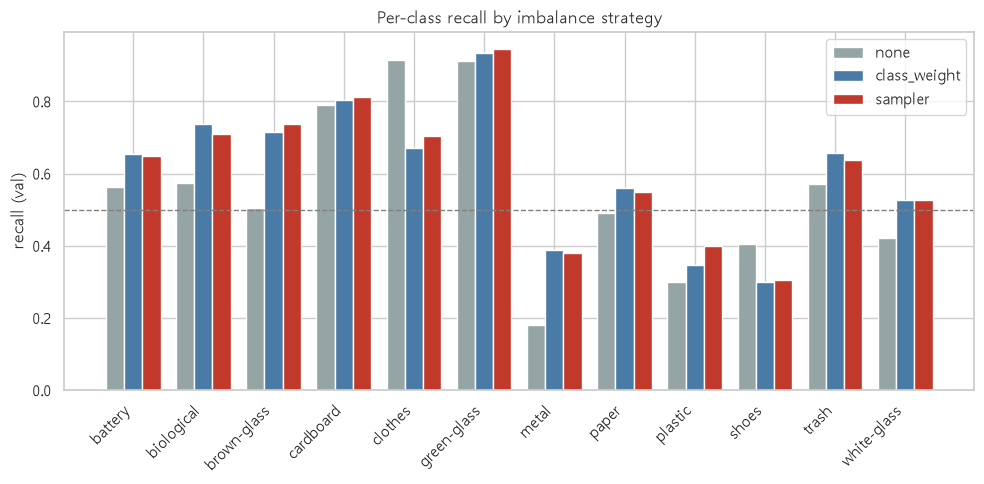

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(N_CLASSES)
width = 0.26
colors = {"none": "#95a5a6", "class_weight": "#4a7ba7", "sampler": "#c0392b"}

for i, s in enumerate(results):
    ax.bar(x + (i - 1) * width, results[s]["recalls"], width, label=s, color=colors[s])

ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45, ha="right")
ax.set_ylabel("recall (val)")
ax.set_title("Per-class recall by imbalance strategy")
ax.axhline(0.5, ls="--", lw=1, color="gray")
ax.legend()
plt.tight_layout()
plt.savefig(OUT / "figures" / "07_recall_by_strategy.png", dpi=150)
plt.show()

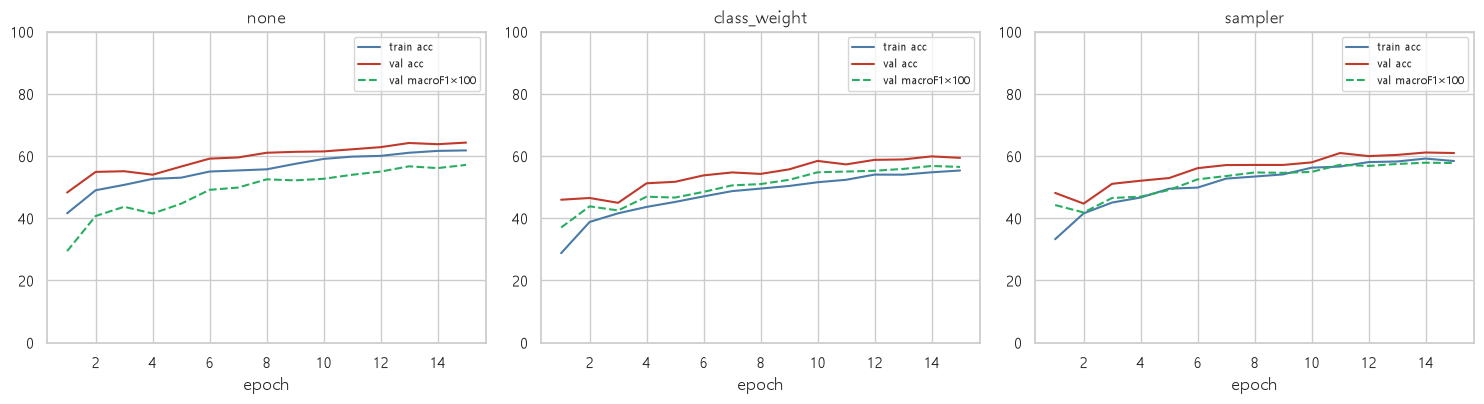

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, s in zip(axes, results):
    h = results[s]["history"]
    ax.plot(h["epoch"], h["train_acc"], label="train acc", color="#4a7ba7")
    ax.plot(h["epoch"], h["val_acc"],   label="val acc",   color="#c0392b")
    ax.plot(h["epoch"], h["val_macro_f1"] * 100, label="val macroF1×100",
            color="#27ae60", ls="--")
    ax.set_title(s); ax.set_xlabel("epoch"); ax.set_ylim(0, 100)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT / "figures" / "08_curves.png", dpi=150)
plt.show()

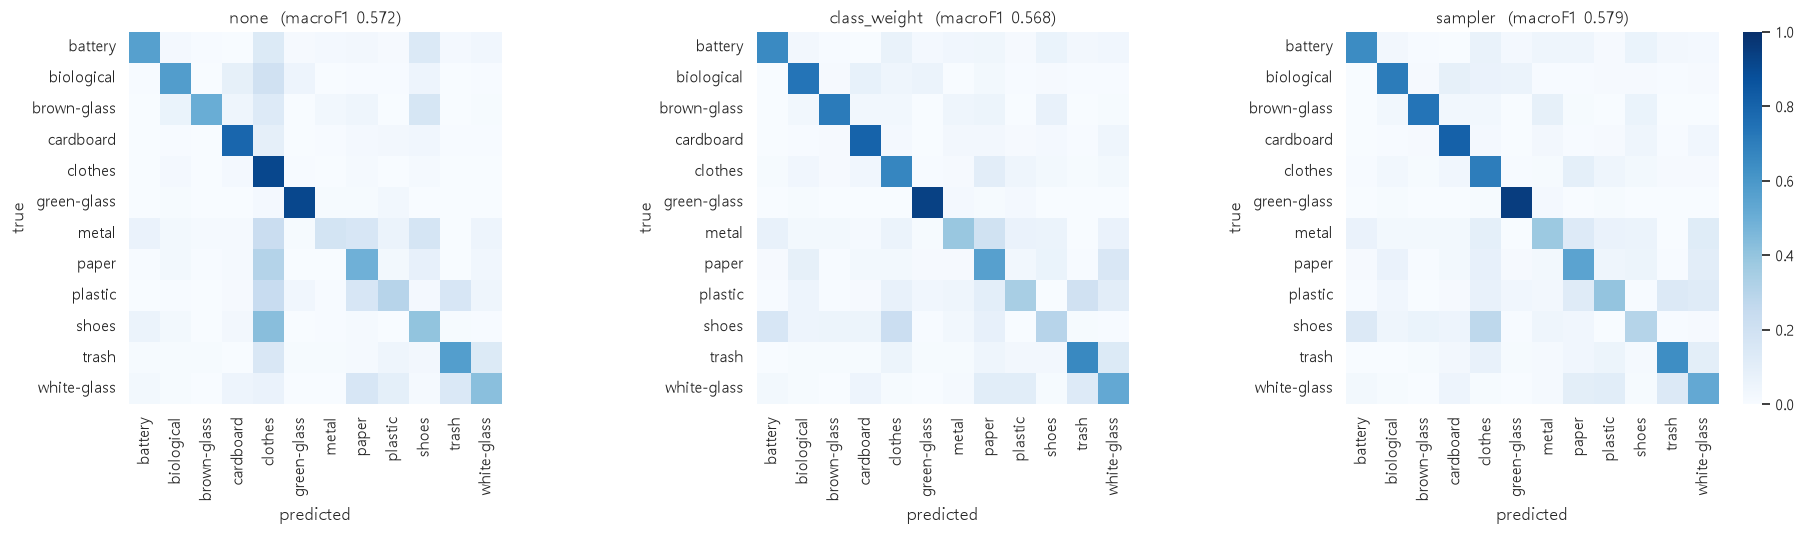

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
for ax, s in zip(axes, results):
    f = results[s]["final"]
    cm = confusion_matrix(f["y_true"], f["y_pred"], labels=range(N_CLASSES))
    cmn = cm / cm.sum(axis=1, keepdims=True)      # 행 정규화 = 클래스별 recall
    sns.heatmap(cmn, ax=ax, cmap="Blues", vmin=0, vmax=1, cbar=(s == "sampler"),
                xticklabels=classes, yticklabels=classes, square=True,
                annot=False)
    ax.set_title(f"{s}  (macroF1 {f['macro_f1']:.3f})")
    ax.set_xlabel("predicted"); ax.set_ylabel("true")

plt.tight_layout()
plt.savefig(OUT / "figures" / "09_confusion.png", dpi=150)
plt.show()

In [14]:
best = summary.sort_values("macro_f1", ascending=False).iloc[0]
print("최종 선택:", best["strategy"], f"(macro_f1 {best['macro_f1']})")
print()
r = results[best["strategy"]]["final"]
print(classification_report(r["y_true"], r["y_pred"],
                            target_names=classes, digits=3, zero_division=0))

최종 선택: sampler (macro_f1 0.5786)

              precision    recall  f1-score   support

     battery      0.605     0.648     0.626       142
  biological      0.610     0.709     0.656       148
 brown-glass      0.650     0.736     0.691        91
   cardboard      0.571     0.812     0.671       133
     clothes      0.787     0.704     0.743       798
 green-glass      0.763     0.946     0.845        92
       metal      0.440     0.379     0.407       116
       paper      0.376     0.548     0.446       157
     plastic      0.391     0.400     0.395       130
       shoes      0.588     0.304     0.401       296
       trash      0.554     0.638     0.593       105
 white-glass      0.424     0.526     0.469       116

    accuracy                          0.611      2324
   macro avg      0.563     0.613     0.579      2324
weighted avg      0.625     0.611     0.608      2324



In [15]:
# 04에서 이어붙일 실험 기록
exp_path = OUT / "metrics" / "experiments.csv"
log = summary.assign(model="GarbageCNN(scratch)", img_size=IMG_SIZE, epochs=EPOCHS)

if exp_path.exists():
    prev = pd.read_csv(exp_path)
    log = pd.concat([prev, log], ignore_index=True).drop_duplicates(
        subset=["model", "strategy"], keep="last")

log.to_csv(exp_path, index=False, encoding="utf-8")
print(log.to_string(index=False))

for s, r in results.items():
    r["history"].to_csv(OUT / "metrics" / f"history_baseline_{s}.csv",
                        index=False, encoding="utf-8")
print("\n체크포인트:", *[p.name for p in sorted((OUT / 'models').glob('baseline_*.pt'))])

    strategy  val_acc  macro_f1  min_recall worst_class  recall_std  minutes               model  img_size  epochs
        none    64.33    0.5715       0.181       metal       0.217     10.0 GarbageCNN(scratch)       128      15
class_weight    59.90    0.5681       0.301       shoes       0.183     10.4 GarbageCNN(scratch)       128      15
     sampler    61.14    0.5786       0.304       shoes       0.181      9.5 GarbageCNN(scratch)       128      15

체크포인트: baseline_class_weight.pt baseline_none.pt baseline_sampler.pt


In [16]:
for s in ["none", "class_weight", "sampler"]:
    h = pd.read_csv(OUT / "metrics" / f"history_baseline_{s}.csv")
    last = h.iloc[-1]
    print(f"{s:14s} train {last['train_acc']:5.1f}%  val {last['val_acc']:5.1f}%  "
          f"gap {last['train_acc'] - last['val_acc']:+5.1f}p")

none           train  61.8%  val  64.3%  gap  -2.5p
class_weight   train  55.4%  val  59.4%  gap  -4.1p
sampler        train  58.4%  val  61.0%  gap  -2.6p


In [17]:
for s in ["none", "class_weight", "sampler"]:
    h = pd.read_csv(OUT / "metrics" / f"history_baseline_{s}.csv")
    last = h.iloc[-1]
    best = h.loc[h["val_macro_f1"].idxmax()]
    print(f"{s:14s} 최종 train {last['train_acc']:5.1f}%  val {last['val_acc']:5.1f}%  "
          f"gap {last['train_acc'] - last['val_acc']:+6.1f}p")
    print(f"{'':14s} best  ep{int(best['epoch']):2d}  val {best['val_acc']:5.1f}%  "
          f"macroF1 {best['val_macro_f1']:.4f}")

none           최종 train  61.8%  val  64.3%  gap   -2.5p
               best  ep15  val  64.3%  macroF1 0.5715
class_weight   최종 train  55.4%  val  59.4%  gap   -4.1p
               best  ep14  val  59.9%  macroF1 0.5681
sampler        최종 train  58.4%  val  61.0%  gap   -2.6p
               best  ep14  val  61.1%  macroF1 0.5786


In [ ]:
# ── 과소적합 대응: 규제 완화 재학습 설정 ──────────────────────────
# 진단 근거: train < val (gap 음수), best epoch이 14~15(마지막)
EPOCHS_V2 = 30
DROP_CONV = 0.10      # 0.25 → 0.10
DROP_FC   = 0.30      # 0.50 → 0.30

train_tf_v2 = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),   # 0.7 → 0.85
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),                                # 15 → 10
    transforms.ColorJitter(brightness=0.2, contrast=0.2,
                           saturation=0.05, hue=0.0),             # 색은 그대로 유지
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

train_ds_v2 = GarbageDataset(train_df, train_tf_v2)


class GarbageCNN_V2(nn.Module):
    def __init__(self, n_classes=N_CLASSES, drop_conv=DROP_CONV, drop_fc=DROP_FC):
        super().__init__()

        def block(cin, cout):
            return nn.Sequential(
                nn.Conv2d(cin, cout, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(cout),
                nn.ReLU(inplace=True),
                nn.Conv2d(cout, cout, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(cout),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2),
                nn.Dropout2d(drop_conv),
            )

        self.features = nn.Sequential(
            block(3, 32), block(32, 64), block(64, 128), block(128, 256))
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Dropout(drop_fc), nn.Linear(256, n_classes))

    def forward(self, x):
        return self.classifier(self.pool(self.features(x)))


print("변경 요약")
print(f"  epochs      15 → {EPOCHS_V2}")
print(f"  Dropout2d   0.25 → {DROP_CONV}")
print(f"  Dropout     0.50 → {DROP_FC}")
print(f"  crop scale  0.70 → 0.85 | rotation 15 → 10")
print(f"  예상 시간   약 {0.63 * EPOCHS_V2:.0f}분")

In [ ]:
def run_relaxed(strategy="sampler", epochs=EPOCHS_V2):
    set_seed(SEED)
    model = init_weights(GarbageCNN_V2()).to(device)

    per_class = cw_df.set_index("label_idx")["class_weight"].to_dict()
    sample_w  = [per_class[t] for t in train_ds_v2.targets]
    sampler   = WeightedRandomSampler(sample_w, num_samples=len(sample_w),
                                      replacement=True)
    train_loader = DataLoader(train_ds_v2, batch_size=BATCH_SIZE, sampler=sampler,
                              num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
    scaler    = amp.GradScaler("cuda")

    ckpt = OUT / "models" / f"baseline_{strategy}_relaxed.pt"
    best_f1, history = -1.0, []
    t0 = time.time()

    print(f"\n[{strategy} / relaxed]  epochs={epochs}  batches/epoch={len(train_loader)}")
    print("=" * 66)

    for ep in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer, scaler)
        va = evaluate(model, val_loader, criterion)
        scheduler.step()

        history.append({"epoch": ep, "train_loss": tr_loss, "train_acc": tr_acc,
                        "val_loss": va["loss"], "val_acc": va["acc"],
                        "val_macro_f1": va["macro_f1"],
                        "lr": optimizer.param_groups[0]["lr"]})

        star = ""
        if va["macro_f1"] > best_f1:
            best_f1 = va["macro_f1"]
            torch.save({"model": model.state_dict(), "strategy": f"{strategy}_relaxed",
                        "epoch": ep, "val_macro_f1": best_f1,
                        "classes": classes, "img_size": IMG_SIZE}, ckpt)
            star = "  *best"

        print(f"  ep{ep:02d}  train {tr_loss:.3f}/{tr_acc:5.1f}%  "
              f"val {va['loss']:.3f}/{va['acc']:5.1f}%  macroF1 {va['macro_f1']:.4f}"
              f"  gap {tr_acc - va['acc']:+5.1f}p{star}")

    elapsed = time.time() - t0
    model.load_state_dict(torch.load(ckpt)["model"])
    final = evaluate(model, val_loader, criterion)
    recalls = recall_score(final["y_true"], final["y_pred"],
                           average=None, labels=range(N_CLASSES), zero_division=0)

    hist = pd.DataFrame(history)
    hist.to_csv(OUT / "metrics" / f"history_baseline_{strategy}_relaxed.csv",
                index=False, encoding="utf-8")

    print(f"\n  완료 {elapsed/60:.1f}분 | best macroF1 {best_f1:.4f} "
          f"(ep{hist['val_macro_f1'].idxmax() + 1})")

    return {"strategy": f"{strategy}_relaxed", "history": hist, "final": final,
            "recalls": recalls, "minutes": elapsed / 60, "best_f1": best_f1}


results["sampler_relaxed"] = run_relaxed("sampler")
torch.cuda.empty_cache()

In [ ]:
a = results["sampler"]
b = results["sampler_relaxed"]

cmp = pd.DataFrame([
    {"setting": "original (ep15, drop .25/.5)",
     "val_acc": round(a["final"]["acc"], 2),
     "macro_f1": round(a["final"]["macro_f1"], 4),
     "min_recall": round(float(a["recalls"].min()), 3),
     "recall_std": round(float(a["recalls"].std()), 3),
     "final_gap": round(a["history"].iloc[-1]["train_acc"]
                        - a["history"].iloc[-1]["val_acc"], 1),
     "best_ep": int(a["history"]["val_macro_f1"].idxmax() + 1),
     "minutes": round(a["minutes"], 1)},
    {"setting": f"relaxed (ep{EPOCHS_V2}, drop {DROP_CONV}/{DROP_FC})",
     "val_acc": round(b["final"]["acc"], 2),
     "macro_f1": round(b["final"]["macro_f1"], 4),
     "min_recall": round(float(b["recalls"].min()), 3),
     "recall_std": round(float(b["recalls"].std()), 3),
     "final_gap": round(b["history"].iloc[-1]["train_acc"]
                        - b["history"].iloc[-1]["val_acc"], 1),
     "best_ep": int(b["history"]["val_macro_f1"].idxmax() + 1),
     "minutes": round(b["minutes"], 1)},
])
cmp.to_csv(OUT / "metrics" / "baseline_relaxed_comparison.csv",
           index=False, encoding="utf-8")
print(cmp.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (name, r) in zip(axes, [("original", a), ("relaxed", b)]):
    h = r["history"]
    ax.plot(h["epoch"], h["train_acc"], label="train acc", color="#4a7ba7")
    ax.plot(h["epoch"], h["val_acc"],   label="val acc",   color="#c0392b")
    ax.set_title(f"{name}  (best ep{int(h['val_macro_f1'].idxmax()) + 1})")
    ax.set_xlabel("epoch"); ax.set_ylim(0, 100); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT / "figures" / "10_relaxed_compare.png", dpi=150)
plt.show()